In [1]:
"""Load data, processes it, save it."""

import argparse
import logging
import pickle
import os
from typing import Dict

import random
import numpy as np
import pandas as pd

from allensdk.brain_observatory.behavior.behavior_project_cache import VisualBehaviorNeuropixelsProjectCache
from tqdm import tqdm

import matplotlib.pyplot as plt
from utils.utils import set_seed

set_seed(42)

logging.basicConfig(level=logging.INFO)

/burg/home/yz4123/.conda/envs/decoding/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


seed set to 42


In [2]:
data_dir = "/burg/stats/users/yz4123/allen_visual_behavior/datasets" 
input_dir = f"{data_dir}/raw"
output_dir = f"{data_dir}/processed"

# get the project cache from the warehouse
manifest_path = os.path.join(input_dir, "manifest.json")
cache = VisualBehaviorNeuropixelsProjectCache.from_s3_cache(cache_dir=data_dir)
# get sessions
sessions = cache.get_ecephys_session_table()

In [3]:
for session_id, row in tqdm(sessions.iterrows()):
    session_id = "1053718935"
    # load nwb file through the allen sdk
    session_data = cache.get_ecephys_session(session_id)
    print(session_data.list_data_attributes_and_methods())
    # stimulus_presentations = session_data.stimulus_presentations

    logging.info(f"Processing session: {session_id}")

    break

0it [00:00, ?it/s]/burg/home/yz4123/.conda/envs/decoding/lib/python3.11/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/project_apis/data_io/behavior_neuropixels_project_cloud_api.py:114: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  session_file_id = str(int(session_meta[self.cache.file_id_column]))
/burg/home/yz4123/.conda/envs/decoding/lib/python3.11/site-packages/hdmf/spec/namespace.py:531: UserWarning: Ignoring cached namespace 'hdmf-common' version 1.8.0 because version 1.5.1 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
/burg/home/yz4123/.conda/envs/decoding/lib/python3.11/site-packages/hdmf/spec/namespace.py:531: UserWarning: Ignoring cached namespace 'core' version 2.6.0-alpha because version 2.5.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already lo

['behavior_data_class', 'behavior_session_id', 'eye_tracking', 'eye_tracking_rig_geometry', 'get_channels', 'get_current_source_density', 'get_lfp', 'get_performance_metrics', 'get_probes_obj', 'get_reward_rate', 'get_rolling_performance_df', 'get_units', 'licks', 'mean_waveforms', 'metadata', 'optotagging_table', 'probes', 'raw_running_speed', 'rewards', 'running_speed', 'spike_amplitudes', 'spike_times', 'stimulus_presentations', 'stimulus_templates', 'stimulus_timestamps', 'task_parameters', 'trials']


In [4]:
def extract_spikes(session, session_id):

    units = session.get_units()
    spiketimes_dict = session.spike_times
    chan_ids = session_data.get_units().peak_channel_id.values

    chan_index = session_data.get_channels().index.values
    chan_region = session_data.get_channels().structure_acronym.values
    chan_dict = dict(zip(chan_index, chan_region))

    region_index = [chan_dict[chan_id] for chan_id in chan_ids]
    print(set(region_index))

    spikes = []
    unit_index = []
    unit_meta = []
    for i, unit_id in enumerate(spiketimes_dict.keys()):
        metadata = units.loc[unit_id]
        unit_name = f"{session_id}/{unit_id}"

        spiketimes = spiketimes_dict[unit_id]
        spikes.append(spiketimes)
        unit_index.append([i] * len(spiketimes))

        unit_meta.append(
            {
                "count": len(spiketimes),
                "id": unit_name,
                "unit_number": i,
            }
        )

    spikes = np.concatenate(spikes)
    unit_index = np.concatenate(unit_index)

    # convert unit metadata to a Data object
    unit_meta_df = pd.DataFrame(unit_meta)
    units = {
        "unit_index": unit_index, 
        "unit_meta_df": unit_meta_df,
        "region_index": region_index,
    }

    return spikes, units

In [54]:
def extract_rewards(session):

    stimulus_presentations = session_data.stimulus_presentations
    stim_blocks = stimulus_presentations.stimulus_block.values
    stim_block_len = [sum(stim_blocks == stim) for stim in set(stim_blocks)]
    chosen_stim_block = np.unique(stim_blocks)[np.argmax(stim_block_len)]
    print(f"Chosen stimulus block {chosen_stim_block} with length {np.max(stim_block_len)}")

    mask = stimulus_presentations.stimulus_block == chosen_stim_block
    stim_block_start = stimulus_presentations.start_time[mask]
    stim_block_end = stimulus_presentations.end_time[mask]
    print(f"Chosen stimulus block start from {stim_block_start.min()} to {stim_block_end.max()}")

    licks = session.licks
    licks_timestamps = licks.timestamps.values.astype(np.float32)

    licks = session_data.licks
    licks_timestamps = licks.timestamps.values.astype(np.float32)
    print(licks_timestamps)
    min_duration = np.min(np.diff(licks_timestamps))
    max_duration = np.max(np.diff(licks_timestamps))
    print(f"Min & Max lick duration: {min_duration:.3f} & {max_duration:.3f} seconds")

    start_time = np.floor(licks_timestamps.min())  
    end_time = np.ceil(licks_timestamps.max())    

    def count_consecutive_runs(arr):
        """Returns total number of runs of 1s and 0s"""
        return np.sum(arr[1:] != arr[:-1])

    # Try multiple bin sizes and pick one with fewest transitions (most consecutive 1s and 0s)
    bin_sizes = np.linspace(min_duration, 1.0, 50)  # try from min gap up to 1 second
    best_score = float('inf')
    best_bin_size = None
    best_binary = None

    for bs in bin_sizes:
        bins = np.arange(start_time, end_time + bs, bs)
        idx = np.digitize(licks_timestamps, bins)
        binary = np.zeros(len(bins))
        binary[np.unique(idx)] = 1
        score = count_consecutive_runs(binary)
        
        if score < best_score:
            best_bins = bins
            best_score = score
            best_bin_size = bs
            best_binary = binary
    print("Best bin size for max consecutive 1s and 0s:", best_bin_size)

    orientations = np.array(best_binary, dtype=np.int32)
    start_times = np.array(bins[:-1], dtype=np.float32)
    end_times = np.array(bins[1:], dtype=np.float32)
    output_timestamps = (
        start_times + (end_times - start_times) / 2
    )
    print(output_timestamps)
    print(orientations)

    return {
        "start": start_times,
        "end": end_times,
        "orientation": orientations,  # (N,)
        "timestamps": output_timestamps,  # (N,)
    }

In [6]:
def extract_running_speed(session):

    running_speed_dict = {}
    running_speed_df = session.running_speed
    if running_speed_df is not None:
        running_speed_df = running_speed_df[~running_speed_df.isnull().any(axis=1)]
        running_speed_times = running_speed_df.timestamps
        running_speed_dict.update(
            {
                "timestamps": running_speed_times.values,
                "running_speed": running_speed_df.speed
                .values.astype(np.float32)
                .reshape(-1, 1),  # continues values needs to be 2 dimensional
            }
        )
    return running_speed_dict

In [7]:
def get_stim_trial_splits(stim_dict, split_ratios=[0.7, 0.1, 0.2]):
    if stim_dict is None or len(stim_dict["timestamps"]) == 0:
        return {"train": None, "val": None, "test": None}
    import math

    train_boundary = math.floor(len(stim_dict["timestamps"]) * split_ratios[0])
    valid_boundary = math.floor(len(stim_dict["timestamps"]) * (split_ratios[0] + split_ratios[1]))
    test_boundary = math.floor(len(stim_dict["timestamps"]) * sum(split_ratios))
    
    stim_trials = np.vstack([stim_dict["start"], stim_dict["end"]]).T
    train_trials = stim_trials[:train_boundary - 1] 
    valid_trials = stim_trials[train_boundary: valid_boundary - 1] 
    test_trials = stim_trials[valid_boundary: test_boundary - 1] 
    
    return {"train": train_trials, "val": valid_trials, "test": test_trials}

In [8]:
def get_behavior_region(running_speed_dict, pupil_dict=None, gaze_dict=None):
    # extract session start and end times
    session_start = min(
        running_speed_dict["timestamps"].min() if running_speed_dict is not None else np.inf,
        pupil_dict["timestamps"].min() if pupil_dict is not None else np.inf,
    )
    session_end = max(
        running_speed_dict["timestamps"].max() if running_speed_dict is not None else 0,
        pupil_dict["timestamps"].max() if pupil_dict is not None else 0,
    )
    assert (
        session_start < session_end
    ), "Atleast one of running_speed, pupil or gaze data must be present."
    return session_start, session_end


def sample_free_behavior_splits(
    start, 
    end, 
    length=1, 
    sample_frac=0.7,
):

    sampled_begs = np.arange(start, end-length, length)
    sampled_ends = np.arange(start+length, end, length)
    all_chunks = np.c_[sampled_begs, sampled_ends]

    num_samples = int(len(all_chunks) * sample_frac)

    sampled_ids = np.random.choice(range(len(all_chunks)), num_samples, replace=False)
    sampled_chunks = all_chunks[sampled_ids]

    num_chunk = len(sampled_chunks)
    train_split = int(num_chunk * 0.7)
    val_split = int(num_chunk * 0.1)
    test_split = num_chunk - train_split - val_split 

    train_chunks = sampled_chunks[:train_split]
    val_chunks = sampled_chunks[train_split:train_split+val_split]
    test_chunks = sampled_chunks[train_split+val_split:]

    return {
        "train": np.array(sorted(train_chunks, key=lambda x: x[0])),
        "val": np.array(sorted(val_chunks, key=lambda x: x[0])),
        "test": np.array(sorted(test_chunks, key=lambda x: x[0])),
    }

In [55]:
# extract behavior and stimuli data
# using dedicated extract_* helpers into a dictionary
supervision_dict = {
    "running_speed": extract_running_speed(session_data),
    "rewards": extract_rewards(session_data),
}

Chosen stimulus block 0 with length 4798
Chosen stimulus block start from 25.211229719043374 to 3626.8909368057934
[  28.59792   28.71203   34.77472 ... 3533.9226  3534.1228  3615.5864 ]
Min & Max lick duration: 0.068 & 215.394 seconds
Best bin size for max consecutive 1s and 0s: 1.0
[  28.5   29.5   30.5 ... 3613.5 3614.5 3615.5]
[0 1 0 ... 0 0 1]


(3589,)


/burg/home/yz4123/.conda/envs/decoding/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/burg/home/yz4123/.conda/envs/decoding/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/burg/home/yz4123/.conda/envs/decoding/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "edgecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/burg/home/yz4123/.conda/envs/decoding/lib/python3.11

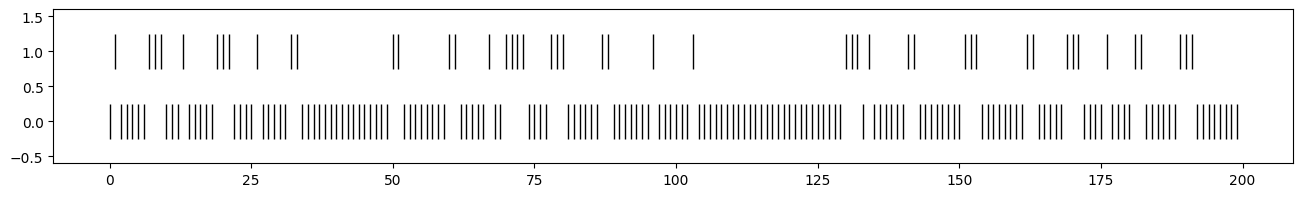

In [56]:
print(supervision_dict["rewards"]["orientation"].shape)
gt = supervision_dict["rewards"]["orientation"][:200]
unique_values = np.unique(gt)
event_positions = [np.where(gt == val)[0] for val in unique_values]

from matplotlib import pyplot as plt
plt.figure(figsize=(16, 2))
plt.eventplot(
    event_positions, 
    colors='k', 
    lineoffsets=np.arange(len(unique_values)), 
    linelengths=0.5, 
    linewidths=1
);

In [ ]:
# split each stimuli/behavior and combine them
# using dedicated get_*_splits helpers into a dictionary
stimuli_splits_by_key = {
    "rewards": get_stim_trial_splits(supervision_dict.get("rewards", None)),
}

In [ ]:
behavior_start, behavior_end = get_behavior_region(
    supervision_dict.get("running_speed", None),
)
free_behavior_splits = sample_free_behavior_splits(behavior_start, behavior_end)

In [ ]:
spikes, units = extract_spikes(session_data, session_id)

session_dict = {"data": {}, "splits": {}}

session_dict["data"] = {
    "spikes": spikes,
    "units": units,
    **supervision_dict,
}

session_dict["splits"] = {
    "free_behavior_splits": free_behavior_splits,
    **stimuli_splits_by_key,
}

In [ ]:
output_dir

In [ ]:
with open(f"{output_dir}/{session_id}.pkl", "wb") as f:
    pickle.dump(session_dict, f)

logging.info(f"Saved to disk session: {session_id}")

In [ ]:
import sys
import uuid
import multiprocessing
from tqdm import tqdm
from iblutil.numerical import bincount2D

def globalize(func):
    def result(*args, **kwargs):
        return func(*args, **kwargs)
    result.__name__ = result.__qualname__ = uuid.uuid4().hex
    setattr(sys.modules[result.__module__], result.__name__, result)
    return result

def bin_spike_count(
    times, 
    units, 
    start, 
    end, 
    binsize=0.01, 
    length=None,
    n_workers=1
):

    num_chunk = len(start)
    if length is None:
        min_length = min(end - start)
        if min_length < 1:
            length = round(min_length, 1)
        else:
            length = int(min_length)
    print(f"Min sequence length: {length}s")
    num_bin = int(np.ceil(length / binsize))

    unit_index = np.unique(units)
    unit_count = len(unit_index)

    @globalize
    def count_spike_per_chunk(chunk):
        chunk_id, t_beg, t_end = chunk
        mask = (times >= t_beg) & (times < t_end)
        times_curr = times[mask]
        clust_curr = units[mask]

        if len(times_curr) == 0:
            spike_per_chunk = np.zeros((unit_count, num_bin))
            tbin_ids = np.arange(unit_count)
        else:
            spike_per_chunk, tbin_ids, unit_ids = bincount2D(
                times_curr, clust_curr, xbin=binsize, xlim=[t_beg, t_end]
            )
            _, tbin_ids, _ = np.intersect1d(unit_index, unit_ids, return_indices=True)

        return spike_per_chunk[:,:num_bin], tbin_ids, chunk_id

    spike_count = np.zeros((num_chunk, unit_count, num_bin))

    chunks = list(zip(np.arange(num_chunk), start, end))

    if n_workers == 1:
        for chunk in tqdm(chunks):
            res = count_spike_per_chunk(chunk)
            spike_count[res[-1], res[1], :] += res[0]
    else:
        with multiprocessing.Pool(processes=n_workers) as pool:
            with tqdm(total=num_chunk) as pbar:
                for res in pool.imap_unordered(count_spike_per_chunk, chunks):
                    pbar.update()
                    spike_count[res[-1], res[1], :] += res[0]
            pbar.close()

    return spike_count

In [ ]:
target = "rewards"
start, end = session_dict["splits"][target]["train"].T

In [ ]:
spike_count = bin_spike_count(
    session_dict["data"]["spikes"], 
    session_dict["data"]["units"]["unit_index"], 
    start=start,
    end=end,
    binsize=0.01,
    length=0.2,
    n_workers=4
)

In [ ]:
plt.imshow(spike_count.mean(0), aspect="auto", cmap="binary")
plt.colorbar()
plt.show()

In [ ]:
target = "rewards"
split = "train"
start, end = session_dict["splits"][target][split].T
target_name = "orientation"
timestamps = session_dict["data"][target]["timestamps"]
behavior = session_dict["data"][target][target_name]
valid_mask = np.any((timestamps[:, None] >= start) & (timestamps[:, None] < end), axis=1)

In [ ]:
from scipy.interpolate import interp1d

def bin_target(
    times, 
    values, 
    start, 
    end, 
    binsize=0.01, 
    length=1,
    n_workers=1, 
):  
    num_chunk = len(start)
    if length is None:
        min_length = min(end - start)
        if min_length < 1:
            length = round(min_length, 1)
        else:
            length = int(min_length)
    num_bin = int(np.ceil(length / binsize))

    start_ids = np.searchsorted(times, start, side="right")
    end_ids = np.searchsorted(times, end, side="left")
    _times_list = [times[s_id:e_id] for s_id, e_id in zip(start_ids, end_ids)]
    _vals_list = [values[s_id:e_id] for s_id, e_id in zip(start_ids, end_ids)]

    times_list = [None for _ in range(len(_times_list))]
    vals_list = [None for _ in range(len(_times_list))]
    valid_mask = [None for _ in range(len(_times_list))]
    skip_reason = [None for _ in range(len(_times_list))]

    @globalize
    def interpolate_func(target):
        chunk_idx, target_time, target_val = target
        target_time, target_val = target_time.squeeze(), target_val.squeeze()

        is_valid, x_interp, y_interp = False, None, None
        
        if len(target_val) == 0:
            skip_reason = "target data not present"
            return chunk_idx, is_valid, x_interp, y_interp, skip_reason
        if np.sum(np.isnan(target_val)) > 0:
            skip_reason = "nans in target data"
            return chunk_idx, is_valid, x_interp, y_interp, skip_reason
        if np.isnan(start[chunk_idx]) or np.isnan(end[chunk_idx]):
            skip_reason = "bad interval data"
            return chunk_idx, is_valid, x_interp, y_interp, skip_reason
        if np.abs(start[chunk_idx] - target_time[0]) > binsize:
            skip_reason = "target data starts too late"
            return chunk_idx, is_valid, x_interp, y_interp, skip_reason
        if np.abs(end[chunk_idx] - target_time[-1]) > binsize:
            skip_reason = "target data ends too early"
            return chunk_idx, is_valid, x_interp, y_interp, skip_reason

        is_valid, skip_reason = True, None
        x_interp = np.linspace(start[chunk_idx] + binsize, end[chunk_idx], num_bin)

        if len(target_val.shape) > 1 and target_val.shape[1] > 1:
            y_interp_list = []
            for n in range(target_val.shape[1]):
                y_interp_list.append(
                    interp1d(
                        target_time, target_val[:,n], kind="linear", fill_value="extrapolate"
                    )(x_interp)
                )
            y_interp = np.hstack([y[:, None] for y in y_interp_list])
        else:
            y_interp = interp1d(
                target_time, target_val, kind="linear", fill_value="extrapolate"
            )(x_interp)
        return chunk_idx, is_valid, x_interp, y_interp, skip_reason

    with multiprocessing.Pool(processes=n_workers) as p:
        targets = list(zip(np.arange(num_chunk), _times_list, _vals_list))
        with tqdm(total=num_chunk) as pbar:
            for res in p.imap_unordered(interpolate_func, targets):
                pbar.update()
                valid_mask[res[0]] = res[1]
                times_list[res[0]] = res[2]
                vals_list[res[0]] = res[3]
                skip_reason[res[0]] = res[-1]
        pbar.close()
        p.close()

    times_out = np.array(times_list)[valid_mask]
    values_out = np.array(vals_list)[valid_mask]
    times_out = np.array([x.flatten() for x in times_out])
    values_out = np.array([x.flatten() for x in values_out])
    valid_mask = np.array(valid_mask)
    
    return times_out, values_out, valid_mask, skip_reason

In [ ]:
times = session_dict["data"]["running_speed"]["timestamps"]
start = session_dict["splits"]["free_behavior_splits"]["train"].T[0]
end = session_dict["splits"]["free_behavior_splits"]["train"].T[1]
start_ids = np.searchsorted(times, start, side="right")
end_ids = np.searchsorted(times, end, side="left")

In [ ]:
# Find remaining trainable region for behavior

_, running_speed, valid_mask, _ = bin_target(
    session_dict["data"]["running_speed"]["timestamps"], 
    session_dict["data"]["running_speed"]["running_speed"], 
    start=session_dict["splits"]["free_behavior_splits"]["train"].T[0],
    end=session_dict["splits"]["free_behavior_splits"]["train"].T[1],
    binsize=0.02,
    n_workers=1
)

In [ ]:
plt.plot(np.arange(400), running_speed.flatten()[:400])
plt.show()


In [ ]:
session_dict["splits"]["rewards"].keys()

In [ ]:
~np.isnan(session_dict["data"]["rewards"]["orientation"])